Basmala Mohamed Aburass 2320222123

Download the required data and libraries



In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/marketing_campaign.csv", sep='\t')

**1. Data Preprocessing (Review & Extension)**

First 5 rows offer

In [8]:
print(df.head())

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

Identifying the data set and column type

In [9]:
df.shape

(2240, 29)

In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Check if there are any empty values

In [11]:
print(df.isnull().sum())

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


Handling missing values ​​in Income
Using median

In [12]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [13]:
print(df.isnull().sum())

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


Feature Engineering(Create Age from Year_Birth)

In [14]:
current_year = 2026
df["Age"] = current_year - df["Year_Birth"]

In [15]:
df.shape

(2240, 30)

Creating TotalSpending(We aggregate all spending)

In [16]:
df["TotalSpending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

In [17]:
df.shape

(2240, 31)

create TotalChildren

In [18]:
df["TotalChildren"] = df["Kidhome"] + df["Teenhome"]

In [19]:
df.shape

(2240, 32)

Remove illogical data:(Age under 18 or over 100 ,Income = 0)

In [20]:
df = df[(df["Age"] >= 18) & (df["Age"] <= 100)]
df = df[df["Income"] > 0]

Encoding
Education

In [21]:
df.Education

,Education
0,Graduation
1,Graduation
2,Graduation
3,Graduation
4,PhD
...,...
2235,Graduation
2236,PhD
2237,Graduation
2238,Master


In [22]:
df["Education"] = df["Education"].replace({
    "Graduation": 1,
    "Master": 2,
    "PhD": 3
})

In [23]:
df.Education

,Education
0,1
1,1
2,1
3,1
4,3
...,...
2235,1
2236,3
2237,1
2238,2



Marital Status (One-Hot Encoding)



In [24]:
top4 = df["Marital_Status"].value_counts().index[:4]
df["Marital_Status"] = df["Marital_Status"].apply(
    lambda x: x if x in top4 else "Other"
)

df = pd.get_dummies(df, columns=["Marital_Status"])

In [25]:
df.shape

(2237, 36)

**2. Supervised Learning - Regression**

Data preparation(where target is Total Spending,train =80% ,test=20%)

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["TotalSpending"])
y = df["TotalSpending"]

X = X.select_dtypes(include=np.number)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Scaling

In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Linear Regression

In [28]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

Ridge Regression

In [29]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

Ridge()

Decision Tree Regressor

In [30]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=5)
tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5)

Evaluation (MSE (Mean Squared Error), RMSE

(Root Mean Squared Error), R² Score

(Measures prediction quality))

In [31]:
from sklearn.metrics import mean_squared_error, r2_score
def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)
    return mse, rmse, r2

results

In [32]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Decision Tree"],
    "MSE": [
        evaluate(lr, X_test_scaled, y_test)[0],
        evaluate(ridge, X_test_scaled, y_test)[0],
        evaluate(tree, X_test, y_test)[0]
    ],
    "RMSE": [
        evaluate(lr, X_test_scaled, y_test)[1],
        evaluate(ridge, X_test_scaled, y_test)[1],
        evaluate(tree, X_test, y_test)[1]
    ],
    "R2": [
        evaluate(lr, X_test_scaled, y_test)[2],
        evaluate(ridge, X_test_scaled, y_test)[2],
        evaluate(tree, X_test, y_test)[2]
    ]
})

print(results)

           Model           MSE          RMSE        R2
0         Linear  7.771551e-25  8.815640e-13  1.000000
1          Ridge  1.627834e-01  4.034643e-01  1.000000
2  Decision Tree  1.626342e+04  1.275281e+02  0.957187


Linear Regression performed best because it achieved the lowest error (MSE and RMSE were very close to zero) and had an R² = 1, meaning its predictions were near perfect.

Ridge Regression gave excellent results, very close to Linear Regression.

Decision Tree was relatively weaker, achieving an R² = 0.957, which explains approximately 95.7% of the data.

**3. Supervised Learning - Classification**

Target:Response

In [33]:
print(df["Response"].value_counts())

Response
0    1903
1     334
Name: count, dtype: int64


We note that the data is imbalanced.

Data segmentation(where target is Response,train =80% ,test=20%)

In [34]:
X = df.drop(columns=["Response"])
X = X.select_dtypes(include=np.number)
y = df["Response"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Logistic Regression(Balance, so that it can take care of customers who have agreed)

In [46]:
from sklearn.linear_model import LogisticRegression

Logistic_model = LogisticRegression(class_weight='balanced')
Logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced')

KNN(Based on the 5 nearest neighbors to the specified point)

In [36]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

Random Forest(Make 100 decision trees instead of one)

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

RandomForestClassifier()

Results

In [48]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_classification(model, X_test, y_test):
    pred = model.predict(X_test)
    print(classification_report(y_test, pred))
    print(confusion_matrix(y_test, pred))

In [49]:
evaluate_classification(Logistic_model, X_test_scaled, y_test)
evaluate_classification(knn, X_test_scaled, y_test)
evaluate_classification(rf, X_test, y_test)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       376
           1       1.00      1.00      1.00        72

    accuracy                           1.00       448
   macro avg       1.00      1.00      1.00       448
weighted avg       1.00      1.00      1.00       448

[[376   0]
 [  0  72]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       376
           1       0.96      0.94      0.95        72

    accuracy                           0.98       448
   macro avg       0.97      0.97      0.97       448
weighted avg       0.98      0.98      0.98       448

[[373   3]
 [  4  68]]
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       376
           1       0.65      0.36      0.46        72

    accuracy                           0.87       448
   macro avg       0.77      0.66      0.69       448
weighted avg       0.85     

As we can see from the comparison, the first model achieved a 100% success rate across all evaluation criteria. The second model achieved 98% accuracy, demonstrating its high reliability. The third model was the weakest.

**4. Unsupervised Learning - Clustering**

In [50]:
Clustering_data = df[[
    "TotalSpending",
    "Income",
    "Age",
    "TotalChildren"
]]

Scaling

In [51]:
scaled_data = StandardScaler().fit_transform(Clustering_data)

Elbow Method

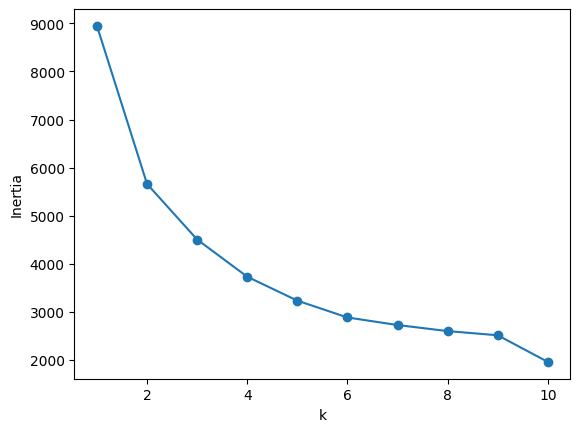

In [53]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

The curve showed a clear elbow at k = 3 where the decrease in inertia became less pronounced.

KMeans

In [43]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df["Cluster"] = clusters

PCA Visualization(To reduce the dimensions from 4 to 2 so that I can visually draw the clusters)

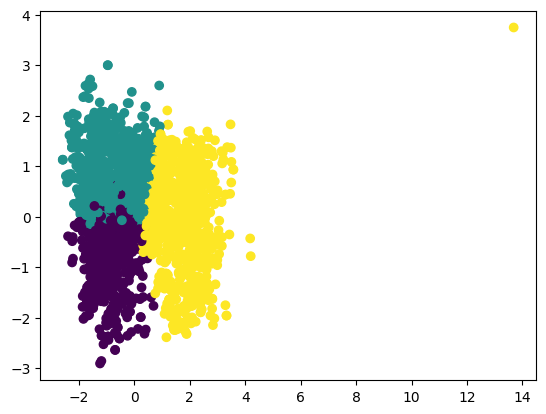

In [54]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(scaled_data)

plt.scatter(reduced[:,0], reduced[:,1], c=clusters)
plt.show()

Cluster Profiling

In [45]:
profile = df.groupby("Cluster")[[
    "Income",
    "TotalSpending",
    "Age",
    "TotalChildren"
]].mean()

print(profile)

               Income  TotalSpending        Age  TotalChildren
Cluster                                                       
0        33235.539295     161.471545  48.714092       0.853659
1        47763.638239     314.640990  64.181568       1.660248
2        74586.422280    1304.582902  58.443005       0.375648


Cluster 0 → Low income and low spending and no children or one
Cluster 1 → Older age, larger family, and average spending
Cluster 2 → High income and very high spending (best customers)